In [1]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 82.0 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()  # select your zip from your computer

Saving archive.zip to archive.zip


In [3]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/archive')

In [4]:
from ultralytics import YOLO

model_name = "yolov8m.pt"
model = YOLO(model_name)

model.train(
        data="/content/archive/data.yaml",
        epochs=75,
        imgsz=640,
        batch=16,
        project="YOLO_Experiments",
        name= "yolov8m"
    )

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/archive/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=75, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hs

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c09c93a94f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [5]:
from ultralytics import YOLO

model = YOLO("runs/detect/YOLO_Experiments/yolov8m/weights/best.pt")
metrics = model.val(data="/content/archive/data.yaml",)

print("Precision :", metrics.box.mp)
print("Recall    :", metrics.box.mr)
print("mAP@50    :", metrics.box.map50)
print("mAP@50-95 :", metrics.box.map)

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 553.2±302.0 MB/s, size: 11.4 KB)
val: Scanning /content/archive/valid/valid/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 12.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.3it/s 1.5s
                   all         30         64      0.796      0.693      0.799      0.504
               crazing          5          8          1      0.214      0.573      0.309
             inclusion          5         15      0.547        0.8      0.723      0.338
               patches          5         17      0.879      0.857       0.97       0.68
        pitted_surface          5          8      0.804      0.875      0.946      0.692
       rolled-in_scale          5          9   

In [6]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/YOLO_Experiments/yolov8m/weights/best.pt")

model.predict(
    source="/content/archive/valid/valid/images",
    save=True,
    conf=0.25
)


image 1/30 /content/archive/valid/valid/images/crazing_1.jpg: 640x640 1 crazing, 36.8ms
image 2/30 /content/archive/valid/valid/images/crazing_2.jpg: 640x640 1 crazing, 37.6ms
image 3/30 /content/archive/valid/valid/images/crazing_3.jpg: 640x640 1 crazing, 37.2ms
image 4/30 /content/archive/valid/valid/images/crazing_4.jpg: 640x640 3 crazings, 36.8ms
image 5/30 /content/archive/valid/valid/images/crazing_5.jpg: 640x640 2 crazings, 39.9ms
image 6/30 /content/archive/valid/valid/images/inclusion_1.jpg: 640x640 6 inclusions, 32.1ms
image 7/30 /content/archive/valid/valid/images/inclusion_2.jpg: 640x640 3 inclusions, 25.3ms
image 8/30 /content/archive/valid/valid/images/inclusion_3.jpg: 640x640 5 inclusions, 32.2ms
image 9/30 /content/archive/valid/valid/images/inclusion_4.jpg: 640x640 4 inclusions, 25.4ms
image 10/30 /content/archive/valid/valid/images/inclusion_5.jpg: 640x640 6 inclusions, 29.4ms
image 11/30 /content/archive/valid/valid/images/patches_1.jpg: 640x640 3 patchess, 21.2ms
i

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'crazing', 1: 'inclusion', 2: 'patches', 3: 'pitted_surface', 4: 'rolled-in_scale', 5: 'scratches'}
 obb: None
 orig_img: array([[[185, 185, 185],
         [175, 175, 175],
         [171, 171, 171],
         ...,
         [102, 102, 102],
         [ 89,  89,  89],
         [ 84,  84,  84]],
 
        [[169, 169, 169],
         [171, 171, 171],
         [195, 195, 195],
         ...,
         [ 96,  96,  96],
         [ 89,  89,  89],
         [107, 107, 107]],
 
        [[192, 192, 192],
         [222, 222, 222],
         [200, 200, 200],
         ...,
         [ 83,  83,  83],
         [118, 118, 118],
         [112, 112, 112]],
 
        ...,
 
        [[253, 253, 253],
         [219, 219, 219],
         [194, 194, 194],
         ...,
         [164, 164, 164],
         [132, 132, 132],
         [123, 123, 123]],
 
        [[255, 255, 

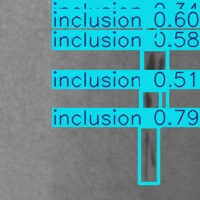

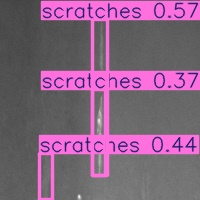

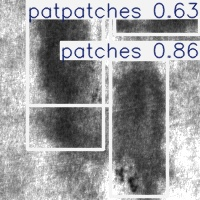

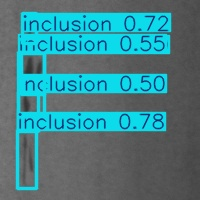

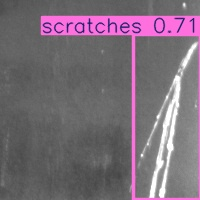

In [8]:
import glob
from IPython.display import Image, display

prediction_files = glob.glob("/content/runs/detect/predict*/*")

prediction_files = [f for f in prediction_files if f.endswith((".jpg", ".jpeg", ".png"))]

for img in prediction_files[:5]:
    display(Image(filename=img))

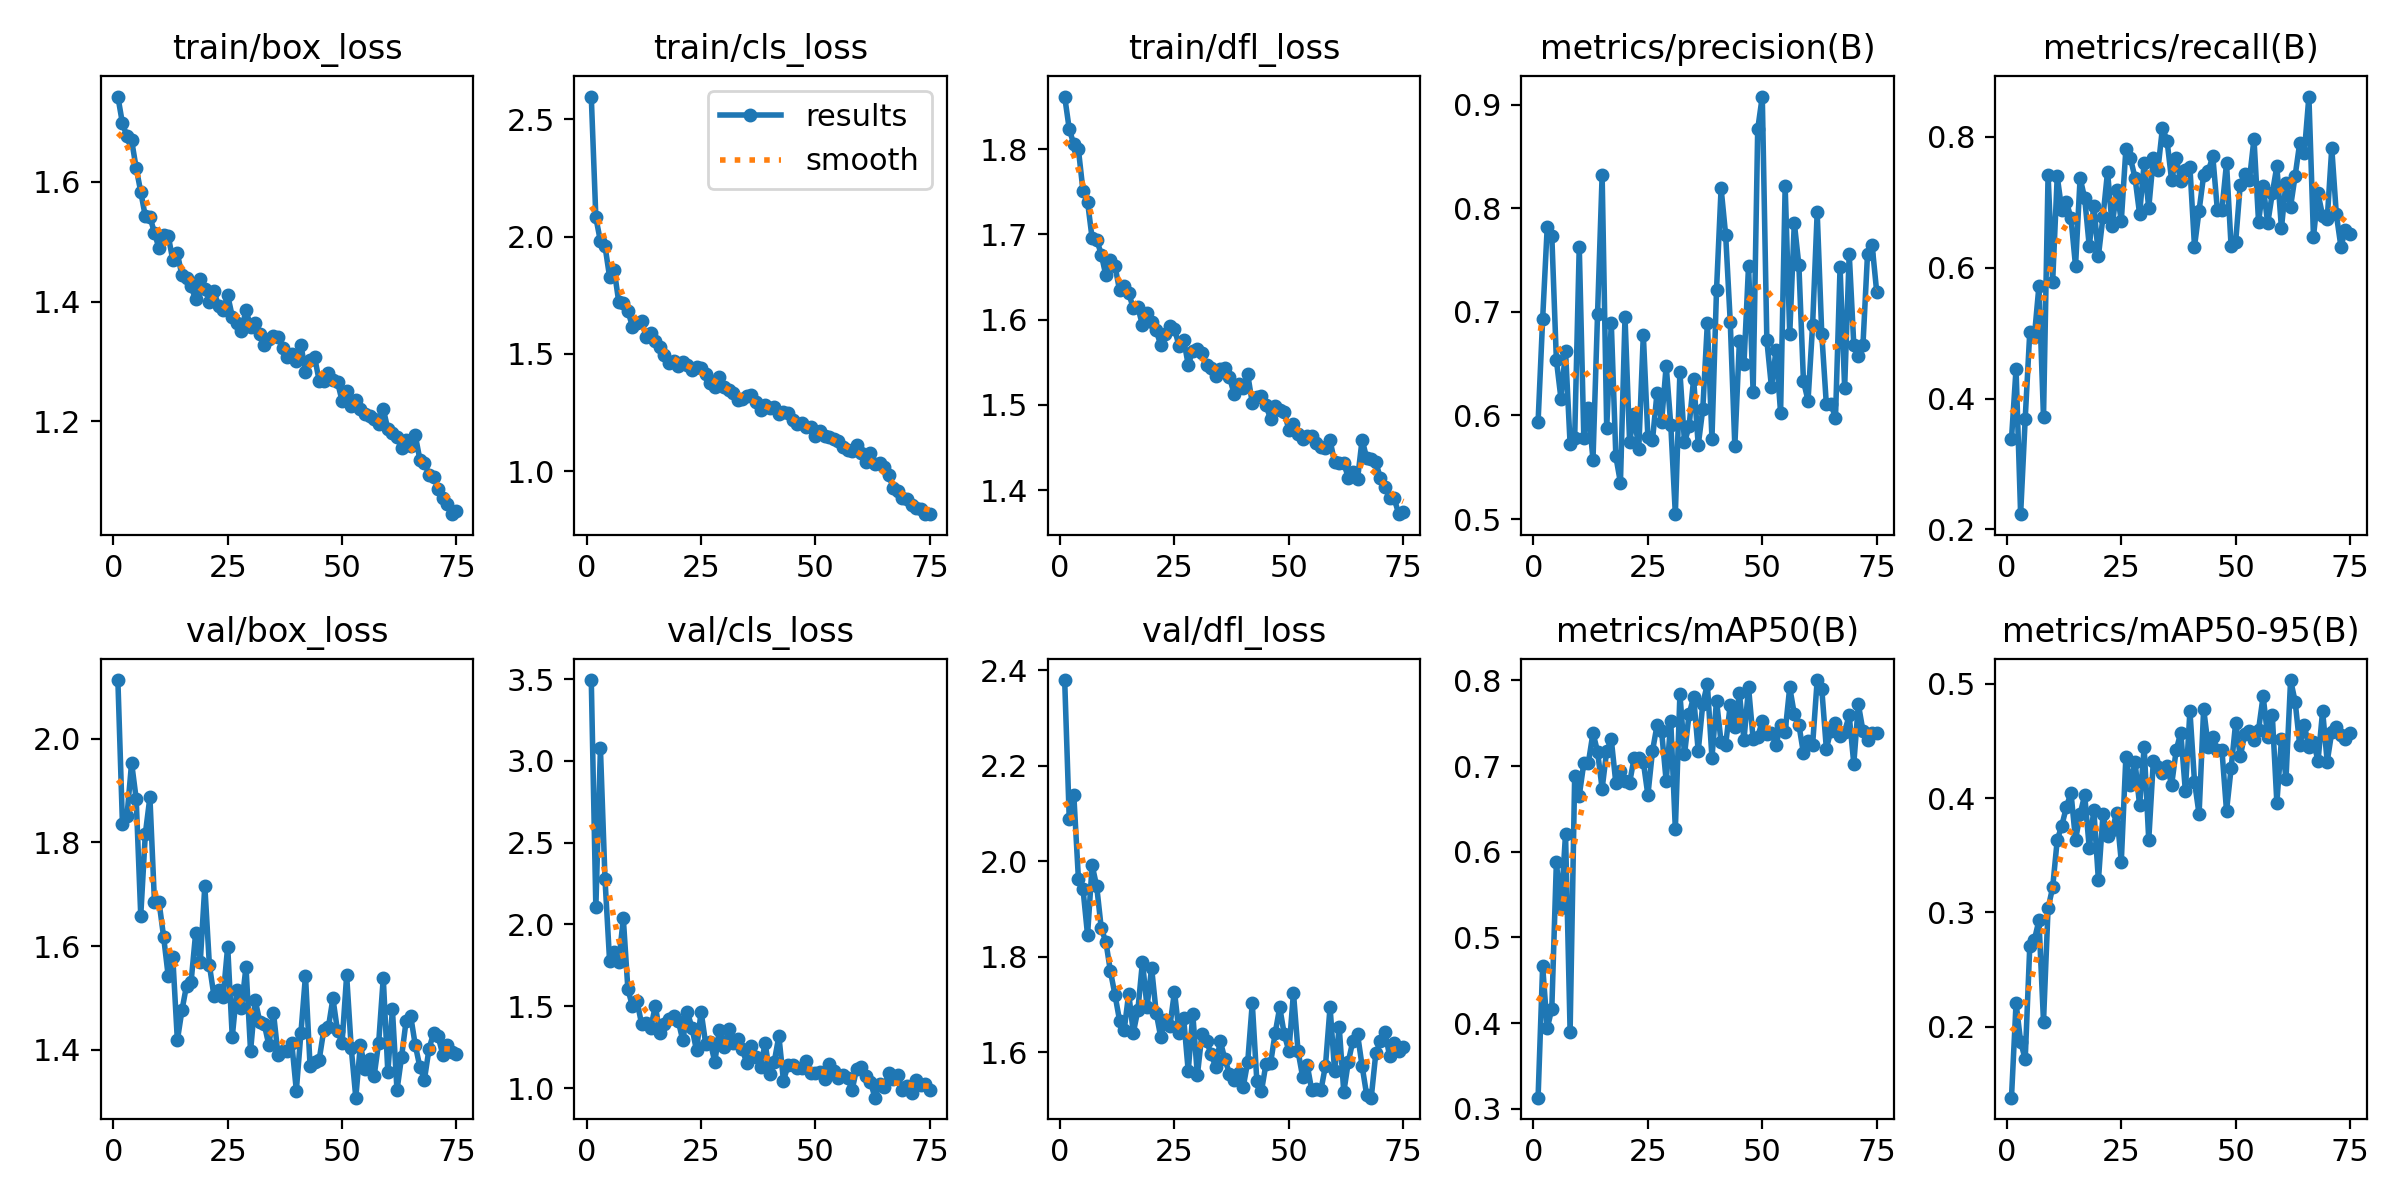

In [9]:
from IPython.display import Image, display

display(Image("/content/runs/detect/YOLO_Experiments/yolov8m/results.png"))

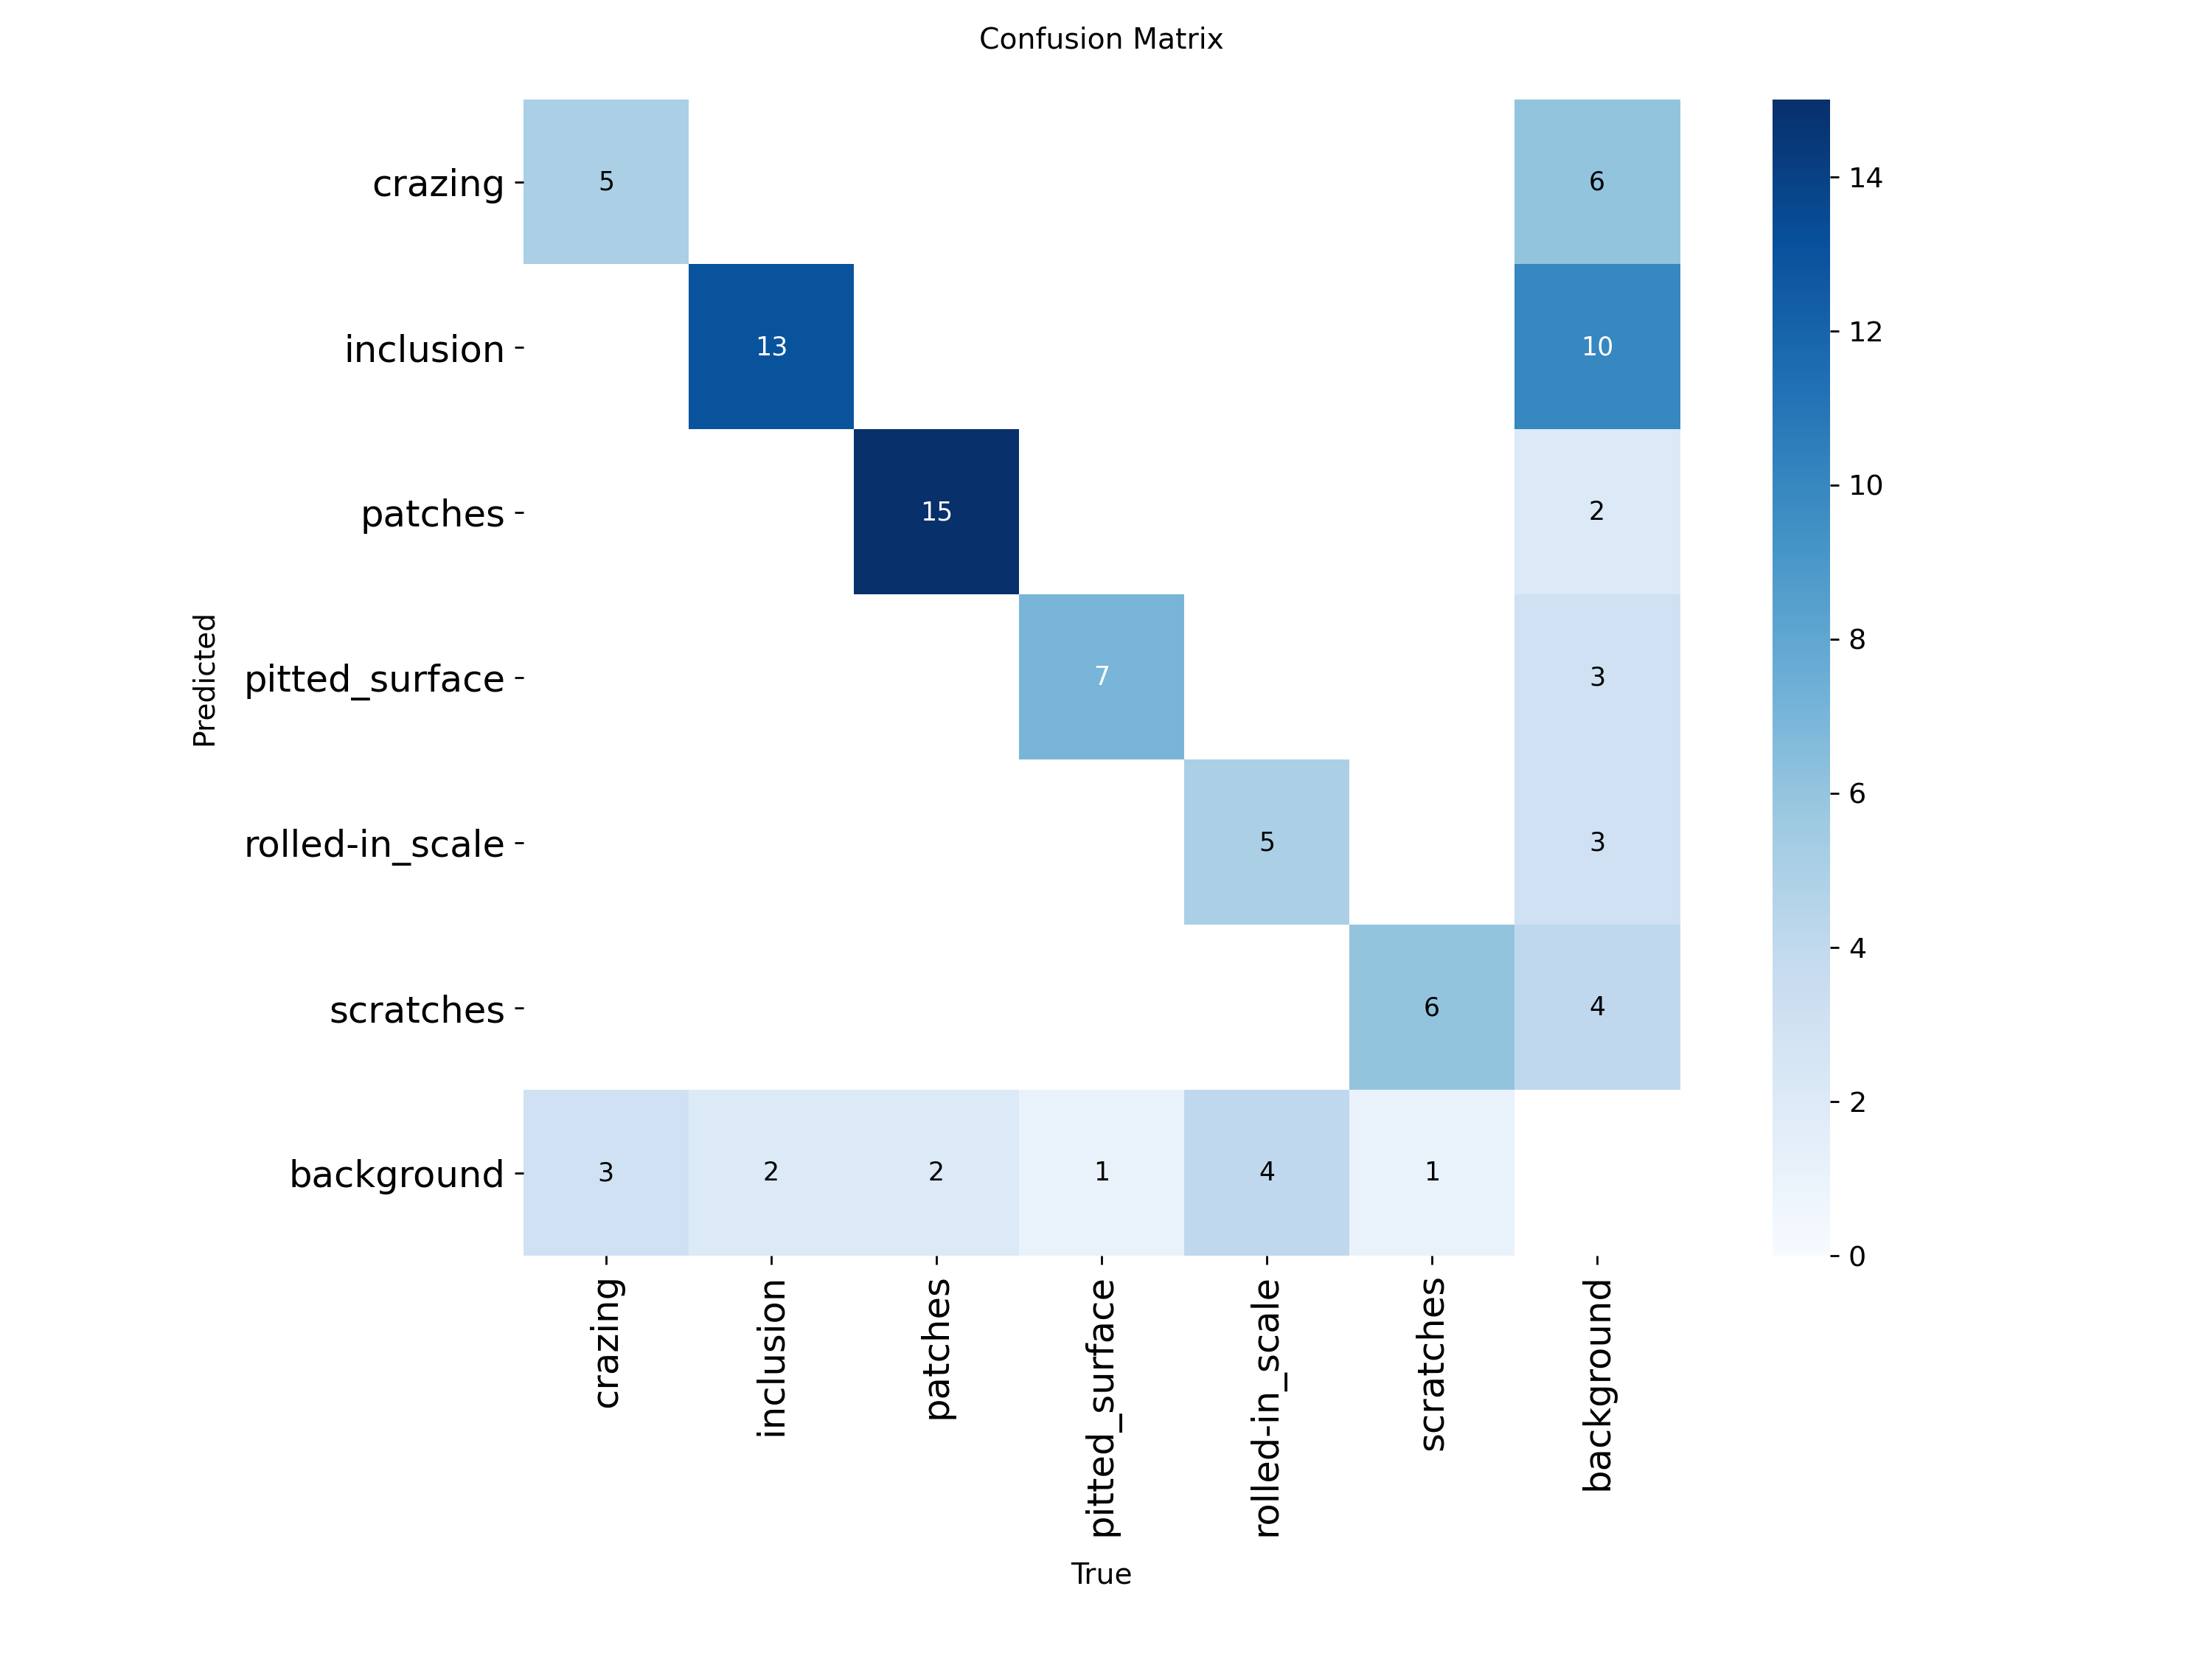

In [10]:
from IPython.display import Image, display

display(Image("/content/runs/detect/YOLO_Experiments/yolov8m/confusion_matrix.png"))